In [4]:
import pandas as pd
import numpy as np


In [5]:
df_matches = pd.read_csv('../../data/preprocessed/imputed_data.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)
season_labels, _ = pd.factorize(df_matches['result_match'])
feature_cols = [col for col in df_matches.columns if col not in
                ["result_match", "stage", "season" ,"date", "home_team", "away_team"]]

y=df_matches['result_match']
X = df_matches[feature_cols]
X

,match_api_id,points_home,points_away,home_last_team_goal,home_last_team_shoton,home_last_team_possession,away_last_team_goal,away_last_team_shoton,away_last_team_possession,team_strength_home,...,rolling_avg_shoton_diff,rolling_stability_shoton_diff,points_diff,rolling_avg_goals_ratio,rolling_stability_goal_ratio,rolling_avg_goals_conversion_rate_ratio,rolling_stability_goals_conversion_rate_ratio,rolling_avg_shoton_ratio,rolling_stability_shoton_ratio,points_ratio
0,489063,3.0,4.0,1.00,12.0,34.0,1.000000,1.0,55.0,78.318182,...,11.00,4.595576e-01,-1.0,1.000000,0.426737,0.083333,1.121929,12.000000,1.201491,0.750000
1,489065,3.0,4.0,2.00,5.0,48.0,1.000000,8.0,51.0,65.136364,...,-3.00,4.484360e-01,-1.0,2.000000,0.599617,3.200000,1.947089,0.625000,1.204236,0.750000
2,489068,3.0,3.0,1.00,7.0,47.0,3.000000,1.0,47.0,63.924242,...,6.00,4.321844e-01,0.0,0.333333,0.840152,0.047619,1.124916,7.000000,1.206472,1.000000
3,489069,3.0,0.0,3.00,5.0,53.0,1.000000,2.0,66.0,71.318182,...,3.00,4.105090e-01,3.0,3.000000,0.602337,1.200000,1.560668,2.500000,1.213780,0.000000
4,489070,4.0,0.0,1.00,5.0,47.0,1.000000,7.0,52.0,63.318182,...,-2.00,4.337160e-01,4.0,1.000000,0.417265,1.400000,1.512672,0.714286,1.210168,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,1987599,44.0,34.0,1.00,4.0,44.0,4.000000,6.0,69.0,72.327273,...,-1.00,1.933017e-01,10.0,0.387097,0.436436,0.998225,4.603260,0.838710,1.077632,1.294118
2974,1987598,49.0,80.0,2.00,5.0,53.0,3.000000,4.0,67.0,65.445455,...,-1.25,-5.252551e-01,-31.0,1.027778,0.762362,1.098123,0.211186,0.800000,0.699854,0.612500
2975,1987597,68.0,17.0,2.00,7.0,31.0,1.666667,1.0,65.0,70.627273,...,3.00,4.440892e-16,51.0,1.239130,1.769303,0.399248,0.159060,1.555556,1.000000,4.000000
2976,1987601,34.0,70.0,1.75,6.0,50.0,1.000000,6.0,47.0,79.690909,...,-2.80,1.407746e+00,-36.0,0.795455,0.635934,2.092939,2.519644,0.562500,2.573908,0.485714


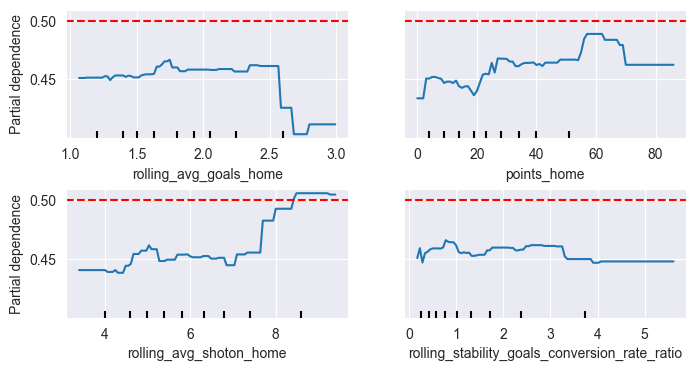

In [6]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

xgb = XGBClassifier(booster='gbtree',
                    objective='reg:logistic',
                    n_estimators=300,
                    max_depth=4,
                    min_child_weight=3)

model_pipeline = Pipeline(
    [('xgboost', xgb)])

model_pipeline.fit(X=X, y=y)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 4)) #B
fig.subplots_adjust(hspace=0.4, wspace=0.2)

PartialDependenceDisplay.from_estimator(model_pipeline,
                                        X=X,
                                        kind='average',
                                        features=['rolling_avg_goals_home',
                                                  'points_home',
                                                  'rolling_avg_shoton_home',
                                                  'rolling_stability_goals_conversion_rate_ratio'],
                                       ax=axes)

for ax in axes.flatten():
    ax.axhline(y=0.5, color='red', linestyle='--') #E

plt.show()